## Annual Customer Sales Segmentation
**6/17/2026 - Project Start**

Data source is `sales_annual_data.xlsx`<br>
Tabs are full year invoiced sales for 2024 and 2025 <br>
> 2024 number of line items = 10,051 <br>
> 2025 number of line items = 12,619 <br>
> Number of unique orders = 11,247 <br>
> Number of unique customers = 1,949 <br>

Goal is to dig deeper into annual sales: <br>
> What makes up our sales orders? <br>
> Are there any patterns regarding customers and orders (buying behavior)? <br>
> What ways can we group customers based on buying behavior? <br>
> Any other questions we may run into. <br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, classification_report

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
#plt.rcParams.update({'figure.facecolor': '#2b2b2b', 'axes.facecolor': '#3a3a3a', 'axes.edgecolor': '#888', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white', 'grid.color': '#555', 'axes.titlecolor': 'white'})

## Check
Checking the data source file. <br>
2025 tab has an extra column `Inv #`, looks like an additional identifier added for accounting department to reference. <br>
Added a `Year` column for reference. <br>

In [2]:
datafile = pd.ExcelFile('sales_annual_data.xlsx')
frames = []
for sheet in datafile.sheet_names:
    d = pd.read_excel('sales_annual_data.xlsx', sheet_name=sheet)
    d['Year'] = sheet
    frames.append(d)

yrs = pd.concat(frames, ignore_index=True)
for yr, ea in yrs.groupby('Year'):
    print(f"{yr} Rows = {len(ea):,}")
    print(f"{yr} Orders = {ea['Ord #'].nunique():,}")
    print(f"{yr} Customers = {ea['Name'].nunique():,}")
    print()
print(f"Total Rows = {len(yrs):,}")
print(f"Total Unique Orders = {yrs['Ord #'].nunique():,}")
print(f"Total Unique Customers = {yrs['Name'].nunique():,}")
print()
print(f"Date Range = {yrs['Inv Dt'].min().date()} to {yrs['Inv Dt'].max().date()}")

yrs.head()

2024 Rows = 10,051
2024 Orders = 5,060
2024 Customers = 1,282

2025 Rows = 12,619
2025 Orders = 6,187
2025 Customers = 1,337

Total Rows = 22,670
Total Unique Orders = 11,247
Total Unique Customers = 1,949

Date Range = 2024-01-02 to 2025-12-31


,Ord #,Type,Code,Inv Dt,Name,Material Cost,Labor Sell Price,Freight Cost,Packaging Cost,Invoiced Amt,Misc Cost,Year,Inv #
0,00253061_45293,V,RL112024,2024-01-02,WNYCSSCTSNC,33.38,44.00,0.00,0.00,172.36,15.00,2024,NaN
1,00253062_45293,V,MW112024,2024-01-02,MNPRCSNDVCSCNC,148.50,30.00,0.00,0.00,298.50,0.00,2024,NaN
2,00253062_45293,V,MW112024,2024-01-02,MNPRCSNDVCSCNC,293.85,0.00,0.00,0.00,462.75,0.00,2024,NaN
3,00253062_45293,V,MW112024,2024-01-02,MNPRCSNDVCSCNC,111.00,0.00,0.00,0.00,175.00,0.00,2024,NaN
4,00253085_45293,D,MW112024,2024-01-02,MNPRCSNDVCSCNC,79.44,0.00,0.00,0.00,148.50,15.00,2024,NaN


## Cleaning and RFM


In [3]:
cost_cols = ['Material Cost', 'Labor Sell Price', 'Freight Cost', 'Packaging Cost', 'Misc Cost']
df = yrs.copy()
df[cost_cols] = df[cost_cols].fillna(0)
df['Total Cost'] = df[cost_cols].sum(axis=1)
df['Margin'] = df['Invoiced Amt'] - df['Total Cost']
orders = df.groupby('Ord #').agg(customer = ('Name', 'first'), inv_date = ('Inv Dt', 'max'), revenue = ('Invoiced Amt', 'sum'), margin = ('Margin', 'sum')).reset_index()
orders.describe()

,inv_date,revenue,margin
count,11247,"11,247.00","11,247.00"
mean,2025-01-17 17:06:19.301147,"2,320.74",862.53
min,2024-01-02 00:00:00,"-27,244.88","-92,670.20"
25%,2024-07-18 00:00:00,274.50,73.65
50%,2025-02-10 00:00:00,792.00,241.10
75%,2025-07-18 00:00:00,"2,091.60",695.30
max,2025-12-31 00:00:00,"116,322.78","54,708.40"
std,NaN,"6,413.62","3,139.25"


For each customer we compute recency, frequency and monetary (RFM) and their profitability. <br>
> `total_revnue` = Lifetime Value (LTV) <br>
> `n_orders` = Frequency of Purchase <br>
> `aov` = Average Order Value <br>
> `total_margin` = Gross Profit <br>
> `margin_pct` = Profitability <br>
> `recency_days` = # of Days Since Last Order <br>  

Exclude customers w/ 0 or less LTV.<br>

In [4]:
snapshot = orders['inv_date'].max() + pd.Timedelta(days=1)
cust = orders.groupby('customer').agg(total_revenue = ('revenue', 'sum'), n_orders = ('Ord #', 'nunique'), total_margin = ('margin', 'sum'), last_order = ('inv_date', 'max')).reset_index()
cust['aov'] = cust['total_revenue'] / cust['n_orders']
cust['margin_pct'] = np.where(cust['total_revenue'] != 0, cust['total_margin'] / cust['total_revenue'], 0)
cust['recency_days'] = (snapshot - cust['last_order']).dt.days
before = len(cust)
cust = cust[cust['total_revenue'] > 0].reset_index(drop=True)

print(f"Number of Good Customers = {len(cust):,} / {before:,}")
cust.describe()

Number of Good Customers = 1,943 / 1,949


,total_revenue,n_orders,total_margin,last_order,aov,margin_pct,recency_days
count,"1,943.00","1,943.00","1,943.00",1943,"1,943.00","1,943.00","1,943.00"
mean,"13,433.54",5.56,"4,993.94",2025-04-12 20:52:29.768399,"2,126.27",0.36,263.13
min,28.75,1.00,"-92,670.20",2024-01-02 00:00:00,28.75,-29.94,1.00
25%,633.00,1.00,208.35,2024-10-24 00:00:00,388.88,0.29,70.00
50%,"2,104.44",2.00,706.38,2025-06-03 00:00:00,929.86,0.37,212.00
75%,"6,750.41",4.00,"2,479.34",2025-10-23 00:00:00,"2,153.70",0.48,434.00
max,"2,109,222.60",665.00,"1,177,793.09",2025-12-31 00:00:00,"61,528.64",1.00,730.00
std,"76,276.02",20.79,"31,164.30",NaN,"4,402.44",0.74,214.37


## Features Chart

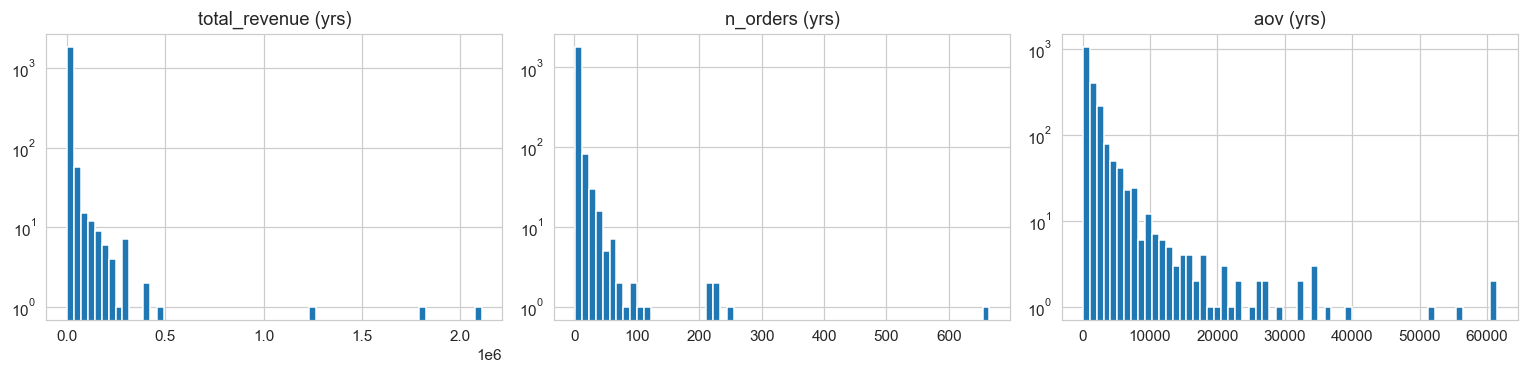

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ['total_revenue', 'n_orders', 'aov']):
    ax.hist(cust[col], bins=60)
    ax.set_title(f'{col} (yrs)')
    ax.set_yscale('log')
plt.tight_layout(); plt.show()

`total_revenue` <br>
> A few high sale customers inbetween 1m to 3m. <br>
> Most customer orders are valued at <= 0.5m w/ a majority being <= 0.1m (100k). <br>

`n_orders`<br>
> Most customers placed anywhere between 1 to 100 orders, leaning towards 1 to 2. <br>

`aov`<br>
> Supports the findings above, w/ much larger amount of small value orders vs. high value. <br>

All three visuals point towards most sales being small orders w/ exceptionally high value orders being very rare. <br>
Need to check if high value orders are "one-off" customers (leaning towards likely). <br>
Also need to see where and how our repeat customers stack. <br>


## Transform and Scale
K-means uses Euclidean distance meaning:<br>
> Very large customers would dominate every distance calculation. <br>
> We apply `log1p` to the heavy-tailed monetary/count features to compress that tail. <br>
> `total_revenue` in millions while `margin_pct` is between 0 and 1. <br>
> Without standardizing revenue alone decides the clusters and margin contributes nothing. We z-score everything so each feature gets an equal vote. <br>

To catch extreme outliers use `margin_pct < -1.0` and report it separately. <br>
Heavy tailed, strictly positive features (`total_revenue`, `n_orders`, `aov`) are log-transformed. <br>
If `total_margin` is negative, it is shifted before the log. <br>
Then standardize to mean ~0 and std ~1. <br>

In [6]:
features = ['total_revenue', 'n_orders', 'aov', 'total_margin', 'margin_pct', 'recency_days']

outlier_mask = cust['margin_pct'] < -1.0
outliers = cust[outlier_mask].copy()
cust = cust[~outlier_mask].reset_index(drop=True)
print(f"Set Aside {len(outliers)} Extreme Outliers Clustering on {len(cust):,} Customers")

if len(outliers):
    display(outliers[['customer', 'total_revenue', 'n_orders', 'margin_pct']].style.hide(axis='index').format({'total_revenue': '${:,.2f}', 'margin_pct': '{:.2%}'}))
    
X = cust[features].copy()
for col in ['total_revenue', 'n_orders', 'aov']:
    X[col] = np.log1p(X[col])

X['total_margin'] = np.log1p(X['total_margin'] - X['total_margin'].min())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled Feature Matrix = {X_scaled.shape}")

summary = pd.DataFrame({'mean': X_scaled.mean(0), 'std': X_scaled.std(0)},index=features).round(2)
display(summary.style)

Set Aside 3 Extreme Outliers Clustering on 1,940 Customers


customer,total_revenue,n_orders,margin_pct
BRDNDSTRS,$454.00,1,-856.83%
CNMDNTRPRSSNC,"$12,491.36",3,-134.47%
VSHGRP,"$3,094.80",1,-2994.38%


Scaled Feature Matrix = (1940, 6)


,mean,std
total_revenue,-0.000000,1.000000
n_orders,0.000000,1.000000
aov,-0.000000,1.000000
total_margin,-0.000000,1.000000
margin_pct,-0.000000,1.000000
recency_days,0.000000,1.000000


## Inertia and Silhouette
We sweep `k` from 2 to 11 and look at two diagnostics:
> `Inertia (Elbow)` = within-cluster sum of squares. <br>
> Always decreases as `k` grows. Look for "elbow" where the marginal gain flattens. <br>
> `Silhouette` = how well-separated the clusters are from -1 to 1 (higher is better). <br>

Absolute values don't mean much, it's the shape across k that guides the choice, and domain sense breaks ties.

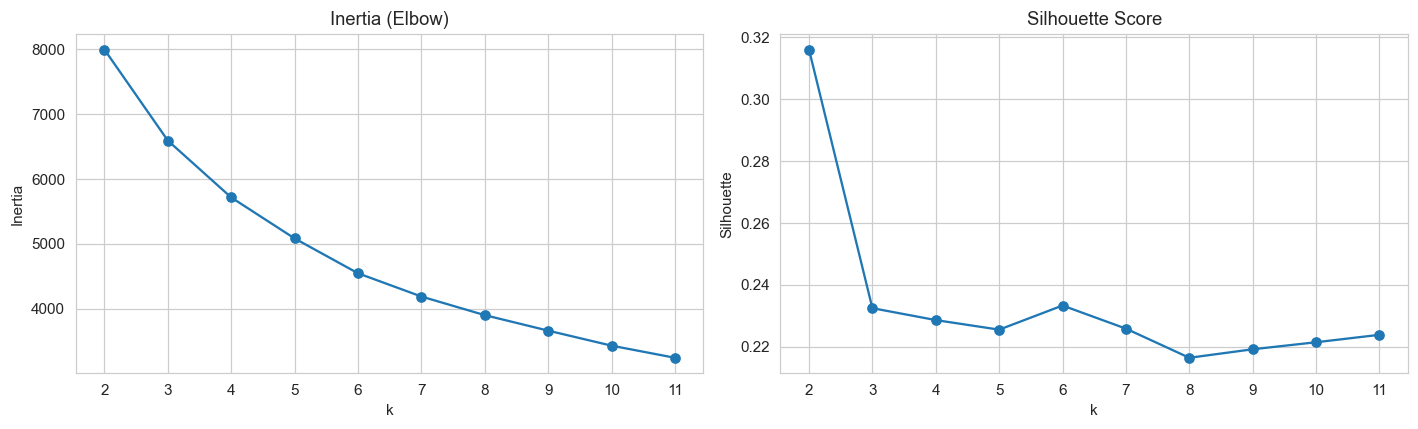

k,inertia,silhouette
2,"7,997",0.316
3,"6,593",0.232
4,"5,715",0.229
5,"5,083",0.226
6,"4,545",0.233
7,"4,187",0.226
8,"3,899",0.216
9,"3,660",0.219
10,"3,428",0.221
11,"3,241",0.224


In [7]:
ks = range(2, 12)
inertias, sils = [], []
life_universe_everything = 42
for k in ks:
    km = KMeans(n_clusters=k, random_state=life_universe_everything, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(ks), inertias, 'o-')
ax1.set(title='Inertia (Elbow)', xlabel='k', ylabel='Inertia')
ax2.plot(list(ks), sils, 'o-')
ax2.set(title='Silhouette Score', xlabel='k', ylabel='Silhouette')
for ax in (ax1, ax2):
    ax.set_xticks(list(ks))
    
plt.tight_layout(); plt.show()
metrics = pd.DataFrame({'k': list(ks), 'inertia': inertias, 'silhouette': sils})
display(metrics.style.hide(axis='index').format({'inertia': '{:,.0f}', 'silhouette': '{:.3f}'}).background_gradient(subset=['silhouette'], cmap='Greens'))

With the extreme outliers removed `silhouette` is now highest at `k = 2` and `inertia` shows a gentle elbow around `k = 3`. <br>
The metric wants fewer clusters but more may be more useful. <br>

> `k = 2` being what `silhouette` prefers, it cleanly splits "key accounts" from "everyone else". <br>
> `k = 3` sits at the `inertia` and splits that long tail into something more actionable (midtier regular customers vs. actual one-off customers) at only a small `silhouette` cost.

`k=3` for actionability will be used moving forward.

In [8]:
the_chosen_one = 3
km = KMeans(n_clusters=the_chosen_one, random_state=life_universe_everything, n_init=10)
cust['cluster'] = km.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, cust['cluster'])
print(f"Silhouette at k={the_chosen_one} is {sil:.3f}")

counts = cust['cluster'].value_counts().sort_index()
sizes = (counts.rename('customers').to_frame().assign(share=lambda d: d['customers'] / d['customers'].sum()))
sizes.index.name = 'cluster'
display(sizes.style.format({'customers': '{:,}', 'share': '{:.1%}'}))

Silhouette at k=3 is 0.232


,customers,share
cluster,,
0,910,46.9%
1,230,11.9%
2,800,41.2%


## Silhouette Clusters
A quick look at per-sample silhouette widths per cluster. <br>
> Fat positive bands mean a cluster hangs together. <br>
> Lots of negative values mean members sit closer to a neighboring cluster.

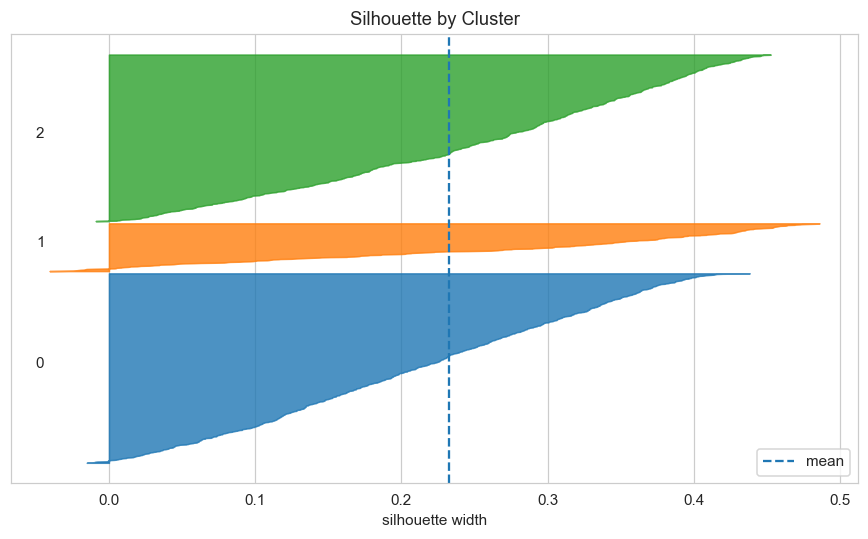

In [9]:
sample_sil = silhouette_samples(X_scaled, cust['cluster'])
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
cmap = plt.cm.tab10
for c in range(the_chosen_one):
    vals = np.sort(sample_sil[cust['cluster'] == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=cmap(c), edgecolor=cmap(c), alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(c))
    y_lower = y_upper + 10
ax.axvline(sample_sil.mean(), ls='--', label='mean')
ax.set(title='Silhouette by Cluster', xlabel='silhouette width', yticks=[])
ax.legend(); plt.tight_layout(); plt.show()

## Profile Segments
What does each cluster actually look like in real dollars, order counts, and margins?

In [10]:
profile = cust.groupby('cluster').agg(customers=('customer', 'count'), avg_revenue=('total_revenue', 'mean'), median_revenue= ('total_revenue', 'median'), avg_orders=('n_orders', 'mean'), avg_aov=('aov', 'mean'), avg_margin_pct=('margin_pct', 'mean'), avg_recency=('recency_days', 'mean'), total_revenue=('total_revenue', 'sum'))
profile['pct_customers'] = 100 * profile['customers'] / profile['customers'].sum()
profile['pct_revenue'] = 100 * profile['total_revenue'] / profile['total_revenue'].sum()
profile.round(2)

,customers,avg_revenue,median_revenue,avg_orders,avg_aov,avg_margin_pct,avg_recency,total_revenue,pct_customers,pct_revenue
cluster,,,,,,,,,,
0,910,"5,886.91","4,000.92",3.52,"2,667.19",0.38,212.66,"5,357,088.93",46.91,20.54
1,230,"87,835.25","35,077.33",27.73,"5,698.86",0.42,89.98,"20,202,106.96",11.86,77.45
2,800,657.67,489.49,1.53,482.19,0.36,369.88,"526,138.02",41.24,2.02


Takeaway is usually the gap between share of customers and hare of revenue, that's where the Pareto picture lives.

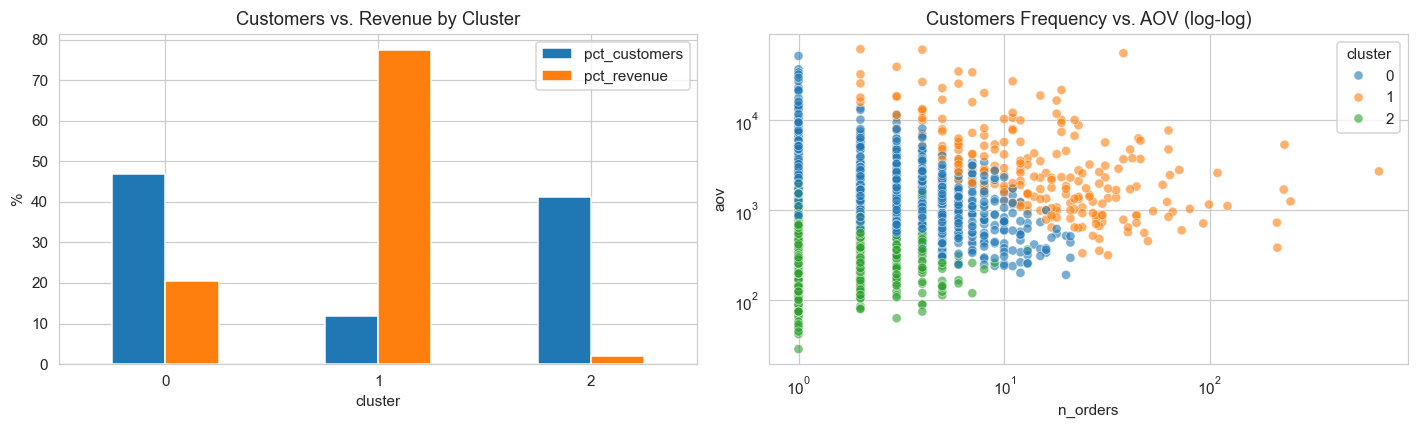

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
profile[['pct_customers', 'pct_revenue']].plot.bar(ax=axes[0])
axes[0].set(title='Customers vs. Revenue by Cluster', ylabel='%', xlabel='cluster')
axes[0].tick_params(axis='x', rotation=0)
sns.scatterplot(data=cust, x='n_orders', y='aov', hue='cluster', palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set(xscale='log', yscale='log', title='Customers Frequency vs. AOV (log-log)')

plt.tight_layout(); plt.show()

## Name Segments
Autorank clusters and add labels based on revenue/frequency/AOV position. <br>
> Clusters are ranked by lifetime revenue (`avg_revenue`). <br>
> Top cluster becomes `Key Accounts`, the lowest becomes the `Occasional / Low-value` long tail, and the rest are `Mid-tier / Growing Accounts`.

In [12]:
p = profile.copy()
order = p['avg_revenue'].rank(ascending=False)
names = {}
for c in p.index:
    r = order[c]
    if r == 1:
        names[c] = 'Key Accounts (high LTV, frequent)'
    elif r == order.max():
        names[c] = 'Occasional / Low-value (the long tail)'
    else:
        names[c] = 'Mid-tier / Growing Accounts'
cust['segment'] = cust['cluster'].map(names)

summary = cust.groupby('segment').agg(customers=('customer','count'), total_revenue=('total_revenue','sum'), avg_aov=('aov','mean'), avg_orders=('n_orders','mean'), avg_margin_pct=('margin_pct','mean')).sort_values('total_revenue', ascending=False)
summary['pct_revenue'] = 100*summary['total_revenue']/summary['total_revenue'].sum()
summary.round(2)

,customers,total_revenue,avg_aov,avg_orders,avg_margin_pct,pct_revenue
segment,,,,,,
"Key Accounts (high LTV, frequent)",230,"20,202,106.96","5,698.86",27.73,0.42,77.45
Mid-tier / Growing Accounts,910,"5,357,088.93","2,667.19",3.52,0.38,20.54
Occasional / Low-value (the long tail),800,"526,138.02",482.19,1.53,0.36,2.02


## Top Customers Segments

In [13]:
for seg in cust['segment'].unique():
    top = (cust[cust['segment'] == seg].nlargest(5, 'total_revenue')[['customer', 'total_revenue', 'n_orders', 'aov']])
    display(top.style.hide(axis='index').format({'total_revenue': '${:,.2f}', 'aov': '${:,.2f}', 'n_orders': '{:,}'}).set_caption(f'Top 5 {seg}'))

customer,total_revenue,n_orders,aov
SMTHWRRNC,"$6,240.00",4,"$1,560.00"
FBRPRCSN,"$4,760.80",13,$366.22
PSSCVLLYWTRCM,"$3,010.00",2,"$1,505.00"
MCMSTRCRRSPPLYC,"$2,862.32",4,$715.58
MZNLB126,"$2,468.07",3,$822.69


customer,total_revenue,n_orders,aov
NVTMTN,"$51,725.00",1,"$51,725.00"
HRSLTRCMPNY,"$36,773.00",1,"$36,773.00"
FNRSRCSNC,"$34,675.68",3,"$11,558.56"
PRDFNSNDSTRSLLC,"$33,939.50",1,"$33,939.50"
MTDSLLC,"$32,338.65",4,"$8,084.66"


customer,total_revenue,n_orders,aov
LFCLLCRPRTN,"$2,109,222.60",38,"$55,505.86"
CLBRSCNTFC,"$1,797,637.43",665,"$2,703.21"
SNDSTRLS,"$1,235,501.73",231,"$5,348.49"
LSNMTRCNTRL,"$485,182.94",63,"$7,701.32"
LMTLNC,"$411,267.24",19,"$21,645.64"


## Segments Review

Does K-means Beat a Manual Rule-based Split? <br>
> For a small number of RFM segments, the clusters mostly agree w/ what simple business rules (key accounts / big-ticket / long-tail) would already give you. <br>
> It found the boundaries instead of guessing thresholds. <br>
> Bring in margin and recency surfaces things pure revenue rules miss (high-revenue but low-margin customer or a loyal customer no longer making orders). <br>
> Auditable and stable rule-based thresholds are easier to defend and justifty. <br>
> K-means is a better exploration tool and serves mainly to validate that a 3-way split is reasonable.<br>

Inertia vs. Silhouette
> Inertia always falls showing where marginal gains taper (the elbow). <br>
> Silhouette measures separation but tends to favor very few clusters on continuous data. <br>
> Both are good to find the sensible range of `k` but ultimately comes down to business actionability for chosen number. <br>

In [14]:
review = cust[['customer', 'segment', 'cluster', 'total_revenue', 'n_orders', 'aov', 'total_margin','margin_pct','recency_days']].sort_values('total_revenue', ascending=False)
review.style.format()

,customer,segment,cluster,total_revenue,n_orders,aov,total_margin,margin_pct,recency_days
809,LFCLLCRPRTN,"Key Accounts (high LTV, frequent)",1,2109222.600000,38,55505.857895,1177793.090000,0.558402,2
166,CLBRSCNTFC,"Key Accounts (high LTV, frequent)",1,1797637.430000,665,2703.214180,340508.470000,0.189420,13
1567,SNDSTRLS,"Key Accounts (high LTV, frequent)",1,1235501.730000,231,5348.492338,18049.037500,0.014609,3
865,LSNMTRCNTRL,"Key Accounts (high LTV, frequent)",1,485182.940000,63,7701.316508,218441.380000,0.450225,27
843,LMTLNC,"Key Accounts (high LTV, frequent)",1,411267.240000,19,21645.644211,156656.630000,0.380912,65
399,DSTKNCRPRTD,"Key Accounts (high LTV, frequent)",1,389499.480000,229,1700.871092,94682.017760,0.243086,13
990,MPLFRRSRCHCRPRTN,"Key Accounts (high LTV, frequent)",1,309967.600000,247,1254.929555,144018.218000,0.464623,2
1053,MTNLBRTRS,"Key Accounts (high LTV, frequent)",1,298700.360000,63,4741.275556,77880.840000,0.260732,1
1469,RTSCRPRTNTH,"Key Accounts (high LTV, frequent)",1,297726.000000,11,27066.000000,112334.430000,0.377308,120
781,L3FZNGNDRDNNCSYSTMSNC,"Key Accounts (high LTV, frequent)",1,297609.590000,18,16533.866111,172177.030000,0.578533,49


## Customer Repeat Prediction
The segmentation above is descriptive and the two-year span makes an honest label possible. <br>
Build features from 2024 behavior only then predict whether the customer placed any order in 2025. <br>

> Target = `returned` (1 = customer ordered again in 2025) <br>
> Features = 2024 RFM + `tenure` (`revenue, orders, AOV, margin, margin %, recency, tenure`) <br>
> Split = 75/25 train/test, stratified on the label <br>
> Baseline = majority-class dummy, so any model has to beat "just predict everyone returns" <br>

In [15]:
d24 = df[df['Year'].astype(int) == 2024].copy()
o24 = d24.groupby('Ord #').agg(customer=('Name', 'first'), inv_date=('Inv Dt', 'max'), revenue=('Invoiced Amt', 'sum'), margin=('Margin', 'sum')).reset_index()
snap24 = o24['inv_date'].max() + pd.Timedelta(days=1)
feat = o24.groupby('customer').agg(total_revenue=('revenue', 'sum'), n_orders=('Ord #', 'nunique'), total_margin=('margin', 'sum'), last_order=('inv_date', 'max'), first_order=('inv_date', 'min')).reset_index()
feat['aov'] = feat['total_revenue'] / feat['n_orders']
feat['margin_pct'] = np.where(feat['total_revenue'] != 0, feat['total_margin']/feat['total_revenue'], 0)
feat['recency_days'] = (snap24 - feat['last_order']).dt.days
feat['tenure_days']  = (feat['last_order'] - feat['first_order']).dt.days
feat = feat[feat['total_revenue'] > 0].reset_index(drop=True)
cust_2025 = set(df[df['Year'].astype(int) == 2025]['Name'].unique())
feat['returned'] = feat['customer'].isin(cust_2025).astype(int)

print(f"Labeled 2024 Customers = {len(feat):,}")
print(f"Return Rate = {feat['returned'].mean():.1%} (returned {feat['returned'].sum():,} / churned {(1-feat['returned']).sum():,})")

model_features = ['total_revenue', 'n_orders', 'aov', 'total_margin', 'margin_pct', 'recency_days', 'tenure_days']
Xc = feat[model_features].copy()
for col in ['total_revenue', 'n_orders', 'aov']:
    Xc[col] = np.log1p(Xc[col])

yc = feat['returned'].values
X_tr, X_te, y_tr, y_te = train_test_split(Xc, yc, test_size=0.25, random_state=life_universe_everything, stratify=yc)
print(f"Train = {len(X_tr):,} | Test = {len(X_te):,}")

Labeled 2024 Customers = 1,276
Return Rate = 52.4% (returned 668 / churned 608)
Train = 957 | Test = 319


In [16]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
rf    = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=life_universe_everything).fit(X_tr, y_tr)
rows = []
for name, m in [('Baseline (majority)', dummy), ('Logistic Regression', logit), ('Random Forest', rf)]:
    proba = m.predict_proba(X_te)[:, 1]
    rows.append({'model': name, 'AUC': roc_auc_score(y_te, proba), 'avg precision': average_precision_score(y_te, proba), 'accuracy': m.score(X_te, y_te)})
    
results = pd.DataFrame(rows)
display(results.style.hide(axis='index').format({'AUC':'{:.3f}', 'avg precision':'{:.3f}', 'accuracy':'{:.3f}'}).background_gradient(subset=['AUC'], cmap='Greens'))

model,AUC,avg precision,accuracy
Baseline (majority),0.500,0.524,0.524
Logistic Regression,0.764,0.791,0.727
Random Forest,0.776,0.802,0.727


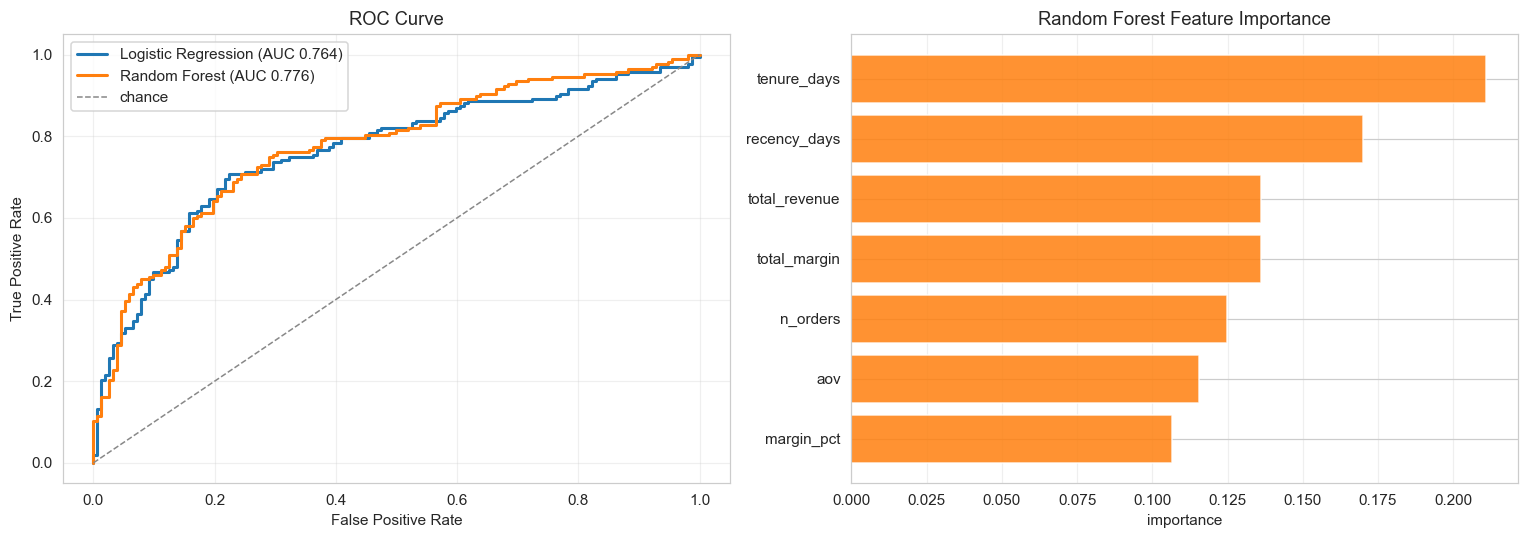

,precision,recall,f1-score,support
churned,0.715,0.711,0.713,152
returned,0.738,0.743,0.740,167
accuracy,0.727,0.727,0.727,0
macro avg,0.727,0.727,0.727,319
weighted avg,0.727,0.727,0.727,319


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, m, col in [('Logistic Regression', logit, 'tab:blue'), ('Random Forest', rf, 'tab:orange')]:
    fpr, tpr, _ = roc_curve(y_te, m.predict_proba(X_te)[:, 1])
    ax1.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC {roc_auc_score(y_te, m.predict_proba(X_te)[:,1]):.3f})')
    
ax1.plot([0,1],[0,1],'--',color='#888',lw=1,label='chance')
ax1.set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax1.legend(); ax1.grid(alpha=0.3)
imp = pd.Series(rf.feature_importances_, index=model_features).sort_values()
ax2.barh(imp.index, imp.values, color='tab:orange', alpha=0.85)
ax2.set(title='Random Forest Feature Importance', xlabel='importance')
ax2.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

report = classification_report(y_te, rf.predict(X_te), target_names=['churned', 'returned'], output_dict=True)
report_df = pd.DataFrame(report).T
report_df['support'] = report_df['support'].astype(int)
display(report_df.style.format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1-score': '{:.3f}', 'support': '{:,}'}).background_gradient(subset=['f1-score'], cmap='Greens'))

The outcome (2025 return) postdates the feature window (2024). <br> 
A held-out test set measures something real rather than leaking future information back into the features. <br>
<br>
Both models clear the majority-class baseline, with AUC around `0.77` and test accuracy near `0.73` versus a `~0.52` floor. <br>
> `tenure` and `recency` carry the most weight. <br>
> Older and more recently active customers from 2024 are more likely to place an order in 2025. <br>
> This lines up and confirms the segmentation (`Key Accounts` churn least, `Occasional` = churn most). <br>

## Summary
What makes up our sales orders?
> Revenue is heavily concentrated in a small set of `Key Accounts`, while a large `Occasional / Low-value` long tail contributes little individually but a lot in aggregate. <br>
> Most customers place very few orders (1–2), and exceptionally high-value orders are generally rare one-off customers. <br>

Are there any patterns regarding customers and orders (buying behavior)?
> Yes, the gap between share of customers and share of revenue is the core pattern. <br>
> A minority of customers drives the majority of revenue. <br>
> Behavior predicts loyalty: using 2024 activity to predict a 2025 return, both models beat the majority-class baseline (`AUC = 0.764`, `accuracy = 0.727` vs. a `floor = 0.524`). <br>
> `tenure` and `recency` carrying the most weight. Older more recently active customers are the most likely to come back. <br>

What ways can we group customers based on buying behavior? 
> A 3-segment split works well. <br>
> K-means on RFM + margin features pointed to `k=2` by silhouette and a gentle elbow near `k=3` by inertia. <br>
> Chose `k=3` for actionability, giving `Key Accounts`, `Mid-tier / Growing`, and the `Occasional / Low-value` tail. <br>
> The clustering mostly agrees with what manual business rules would produce. <br>
> Adds value by folding in margin and recency, surfacing high-revenue / low-margin and loyal "dormant" customers a pure-revenue rule would miss. <br>
> The segmentation and the churn model reinforce each other: `Key Accounts` churn least, `Occasional` churn most.
